## Affichage dynamique de la train loss et val loss pendant l'entraînement

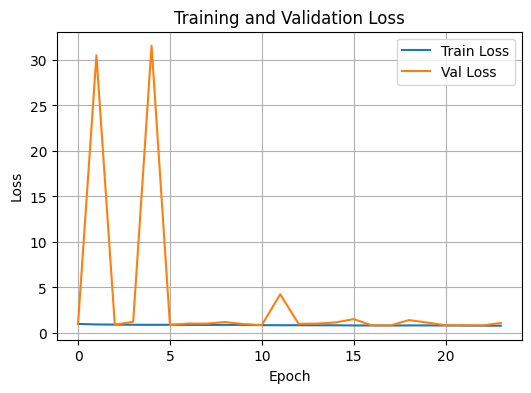

Affichage arrêté par l'utilisateur


In [1]:
import json
import matplotlib.pyplot as plt
import time
import os
from IPython.display import clear_output

# utiliser le même dossier de sauvegarde que dans Mammo.ipynb
save_dir = r"C:\Users\Invite\Documents\safe"
# chemins candidats (save_dir prioritaire, fallback vers ./checkpoints)
candidates = [
    os.path.join(save_dir, "losses_log.json"),
    os.path.join(os.getcwd(), "checkpoints", "losses_log.json"),
    os.path.join(os.getcwd(), "losses_log.json"),
]
# choisir le premier existant ou le premier candidat comme défaut
for p in candidates:
    if os.path.exists(p):
        log_file = p
        break
else:
    log_file = candidates[0]

fig, ax = plt.subplots(figsize=(6,4))

try:
    while True:
        if os.path.exists(log_file):
            try:
                with open(log_file, "r") as f:
                    losses = json.load(f)
            except (json.JSONDecodeError, ValueError):
                time.sleep(0.5)
                continue

            if isinstance(losses, dict) and 'train' in losses and 'val' in losses:
                clear_output(wait=True)         
                fig, ax = plt.subplots(figsize=(6,4))
                ax.plot(losses['train'], label='Train Loss')
                ax.plot(losses['val'], label='Val Loss')
                ax.set_xlabel('Epoch')
                ax.set_ylabel('Loss')
                ax.set_title('Training and Validation Loss')
                ax.legend()
                ax.grid(True)
                plt.show()

        time.sleep(1)  # relire toutes les secondes
except KeyboardInterrupt:
    print("Affichage arrêté par l'utilisateur")

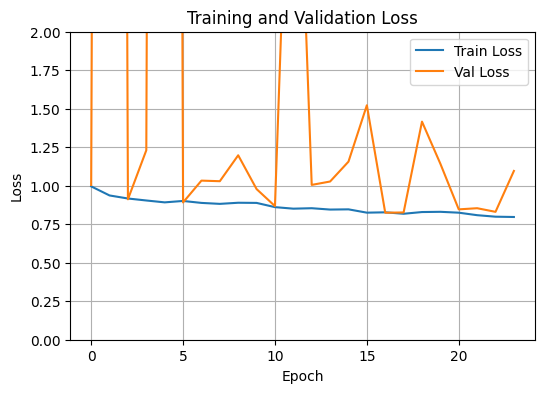

Affichage arrêté par l'utilisateur


In [5]:
import json
import matplotlib.pyplot as plt
import time
import os
from IPython.display import clear_output

# utiliser le même dossier de sauvegarde que dans Mammo.ipynb
save_dir = r"C:\Users\Invite\Documents\safe"
# chemins candidats (save_dir prioritaire, fallback vers ./checkpoints)
candidates = [
    os.path.join(save_dir, "losses_log.json"),
    os.path.join(os.getcwd(), "checkpoints", "losses_log.json"),
    os.path.join(os.getcwd(), "losses_log.json"),
]
# choisir le premier existant ou le premier candidat comme défaut
for p in candidates:
    if os.path.exists(p):
        log_file = p
        break
else:
    log_file = candidates[0]

fig, ax = plt.subplots(figsize=(6,4))


try:
    while True:
        if os.path.exists(log_file):
            try:
                with open(log_file, "r") as f:
                    losses = json.load(f)
            except (json.JSONDecodeError, ValueError):
                time.sleep(0.5)
                continue

            if isinstance(losses, dict) and 'train' in losses and 'val' in losses:
                clear_output(wait=True)         
                fig, ax = plt.subplots(figsize=(6,4))
                ax.plot(losses['train'], label='Train Loss')
                ax.plot(losses['val'], label='Val Loss')
                ax.set_xlabel('Epoch')
                ax.set_ylabel('Loss')
                ax.set_title('Training and Validation Loss')
                ax.legend()
                ax.grid(True)
                ax.set_ylim(0, 2)   # <-- limiter l'axe des ordonnées entre 0 et 1
                plt.show()

        time.sleep(1)  # relire toutes les secondes
except KeyboardInterrupt:
    print("Affichage arrêté par l'utilisateur")
